# Tarea 3: Clasificación de galaxias con una CNN

En esta tarea trabajarán con una versión binaria del dataset [**Galaxy10 DECaLS**](https://astronn.readthedocs.io/en/latest/galaxy10.html). El objetivo es entrenar una red neuronal convolucional simple para clasificar imágenes de galaxias en dos clases:

- **Round Smooth Galaxies**
- **Barred Spiral Galaxies**

La idea no es obtener el mejor modelo posible, sino entender cómo una CNN aprende patrones visuales, cómo se evalúa su desempeño y en qué casos se equivoca.

## Consideraciones
- La tarea se hace en grupos máximos de **2 personas**
- Debe realizar todas las actividades descritas más abajo y responder y comentar lo que se pide.
- **La tarea se entrega el día viernes 07/08, 23:59 horas.**

--

## Actividades

1. **Exploración de datos**
   - Visualice imágenes aleatorias de ambas clases
   - ¿Qué diferencias visuales observa entre las galaxias smooth y las barred spiral?
   - ¿Qué características espera que pueda aprender la red?
   - ¿Cuál es la proporción entre la clases? ¿Cuál sería el accuracy de predecir la clase más frecuente?
     
2. **Preparación de datos**
   - Separe los datos en conjuntos de entrenamiento, validación y test
   - Justifique brevemente por qué es importante tener estos tres conjuntos
     
3. **Arquitectura de la red** (ver más abajo **"Guía para diseñar la CNN"**)
   - Entrene una CNN simple para clasificación binaria
   - Describa la arquitectura utilizada e indique:
        - cuántas capas convolucionales usó
        - qué función de activación escogió
        - si usó pooling, dropout u otra técnica
        - qué función de pérdida utilizó
     - Justifique brevemente estas elecciones. Para esto, puede servir describir el proceso de prueba y error con otras arquitecturas, mostrar y comparar desempeños, o su intuición al elegir la arquitectura  
       
4. **Entrenamiento**
   - Grafique las curvas de pérdida y accuracy para entrenamiento y validación
   - A partir de estas curvas, comente si observa overfitting, underfitting o un entrenamiento razonable
     
5. **Evaluación del modelo**
   - Evalúe el modelo en el conjunto de test usando:
        - accuracy
        - matriz de confusión
        - precision, recall y F1-score
    - ¿El accuracy por sí solo es suficiente para evaluar este modelo? Justifique
      
6. **Análisis de errores**
   - Muestre algunos ejemplos de imágenes mal clasificadas. ¿Parecen errores claros del modelo o casos morfológicamente ambiguos?
   - Considere aspectos como inclinación, bajo brillo, barras débiles, contaminación por objetos cercanos o baja resolución

7. **Comentario final**
   - A partir de sus resultados, discuta brevemente si el modelo parece estar aprendiendo diferencias morfológicas reales entre galaxias suaves y galaxias espirales barradas, o si podría estar usando otros patrones de las imágenes.

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, precision_score,
                             recall_score, f1_score)

import tensorflow as tf
from tensorflow.keras import layers, models

## Configuración de sesión de colab
Debemos trabajar en Google Colab, que tiene la ventaja de tener tensorflow y Keras ya instalado y además levanta un servidor de GPU suficiente para el propósito de esta tarea.  
Para activarlo, debe ir a `Runtime -> Change runtime type -> Hardware accelerator -> T4 GPU`.

Si lo cambió exitosamente, el siguiente comando no debiera ser un array vacío, sino indicar que  `device_type=GPU`

In [ ]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
#monte su cuenta de google drive para trabajar en una carpeta ahí. Le pedirá autentificación
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Los datos de Galaxy10 DECaLS vienen de un dataset de Kaggle, con las clases que estudiaremos ya seleccionadas. Más detalles [acá.](https://www.kaggle.com/datasets/anth0nym/galaxy10-decals-fork-dataset)

In [ ]:
path = "/content/drive/MyDrive/Binary_2_5_dataset.h5" #cambie este path al correspondiente suyo, en su carpeta drive

with h5py.File(path, "r") as f:
    images = np.array(f["images"])
    labels = np.array(f["labels"], dtype="int32")

print(images.shape)
print(labels.shape)

classes, counts = np.unique(labels, return_counts=True)
for c, n in zip(classes, counts):
    print(c, n)

(4688, 256, 256, 3)
(4688,)
0 2645
1 2043


## Estructura de los datos

El dataset contiene **4688 imágenes de galaxias**, cada una con tamaño **256 × 256 píxeles** y **3 canales de color**. Por eso, el arreglo de imágenes tiene la forma:

(4688, 256, 256, 3)

In [ ]:
#X

In [ ]:
X = images
y = labels.astype("int32")

Para visualizar las imágenes

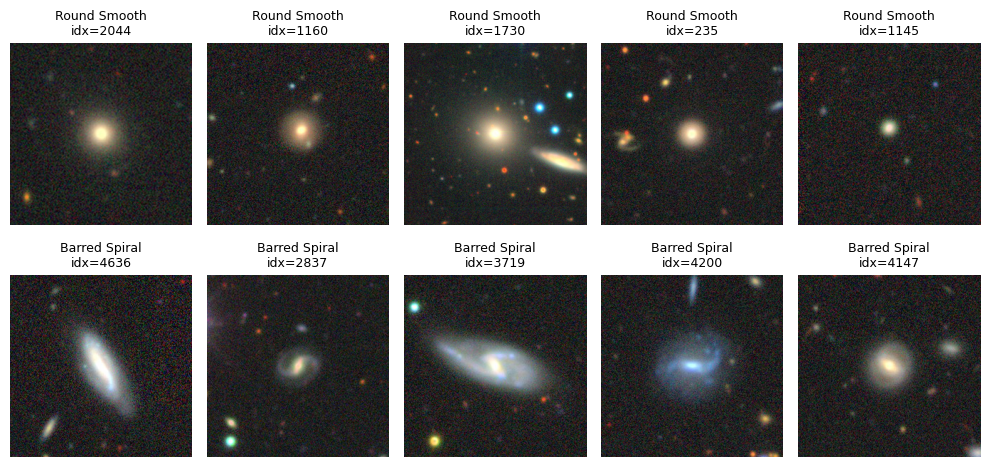

In [ ]:
class_names = {
    0: "Round Smooth",
    1: "Barred Spiral"
}

rng = np.random.default_rng(42)  # semilla para que sea reproducible

#Visualiza 5 imágenes aleatorias de cada clase

plt.figure(figsize=(10, 5))

for class_id in [0, 1]:
    idxs = np.where(labels == class_id)[0]
    sample_idxs = rng.choice(idxs, size=5, replace=False)

    for j, idx in enumerate(sample_idxs):
        plt.subplot(2, 5, class_id * 5 + j + 1)
        plt.imshow(images[idx])
        plt.title(f"{class_names[class_id]}\nidx={idx}", fontsize=9)
        plt.axis("off")

plt.tight_layout()
plt.show()

**Respuestas: Exploración de datos**

- **Diferencias visuales:** las galaxias *Smooth* se ven como manchas de luz ovaladas/circulares con brillo que decae suavemente desde el centro, sin estructura interna. Las *Barred Spiral* muestran una estructura alargada que cruza el núcleo y en varios casos, brazos espirales o grumos de formación estelar que rompen la simetría radial.
- **Características que se espera que la red aprenda:** gradientes de brillo y bordes (para distinguir el contorno difuso de una barra recta), grado de simetría radial vs. elongación, y texturas locales asociadas a brazos espirales.
- **Proporción entre clases:** el dataset tiene 4688 imágenes, con **2645 Round Smooth (56.42%)** y **2043 Barred Spiral (43.58%)**. Hay un desbalance moderado a favor de la clase Round Smooth.
- **Accuracy de predecir siempre la clase más frecuente:** 2645/4688 = **56.42%**. Cualquier modelo entrenado debería superar claramente este valor para considerarse útil.

## Sets de entrenamiento, validación y prueba

Divida el dataset en entrenamiento, validación y prueba. Verifique que la fracción de las clases es similar en todos los sets

In [ ]:
# Split 70% train / 15% val / 15% test, estratificado por clase
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("Train classes:", np.unique(y_train, return_counts=True))
print("Val classes:", np.unique(y_val, return_counts=True))
print("Test classes:", np.unique(y_test, return_counts=True))

Train: (3281, 256, 256, 3) (3281,)
Val: (703, 256, 256, 3) (703,)
Test: (704, 256, 256, 3) (704,)
Train classes: (array([0, 1], dtype=int32), array([1851, 1430]))
Val classes: (array([0, 1], dtype=int32), array([397, 306]))
Test classes: (array([0, 1], dtype=int32), array([397, 307]))


**Preparación de datos**

- **Entrenamiento (3281 imágenes, 1851 Round Smooth / 1430 Barred Spiral):** es el conjunto que la red usa directamente para ajustar sus pesos (forward pass + backpropagation).
- **Validación (703 imágenes, 397 / 306):** no se usa para actualizar pesos, sirve para monitorear el desempeño en datos no vistos durante el entrenamiento, detectar overfitting y decidir cuándo detener el entrenamiento (EarlyStopping, monitor="val_loss").
- **Test (704 imágenes, 397 / 307):** se usa una sola vez al final y es para estimar el desempeño real del modelo sobre datos completamente nuevos. Si se usara el mismo conjunto para ajustar el modelo y para evaluarlo, la estimación de desempeño sería optimista y poco confiable.

Se usó stratify=y en ambos splits, por lo que la proporción de clases se mantuvo prácticamente igual en los tres conjuntos (~56% Round Smooth / ~44% Barred Spiral en train, val y test), evitando que por azar algún conjunto quedara desbalanceado respecto a los otros.

## Guía para diseñar la CNN

Para esta tarea deben proponer una red convolucional simple usando
Keras. No existe una única arquitectura correcta, pero su diseño debe estar justificado.

Una CNN para este problema debería incluir, al menos:

- capas convolucionales, para aprender patrones locales en la imagen;
- alguna forma de reducción espacial, como `MaxPooling2D`;
- una parte final densa o de agregación, para hacer la clasificación;
- una capa de salida adecuada para clasificación binaria.

<figure>
  <img src="https://www.astroml.org/astroML-notebooks/_images/fig_cnn_1.png" alt="ejemplo CNN" width="500" height="300">
  <figcaption>Ejemplo arquitectura CNN</figcaption>
</figure>




Al diseñar la arquitectura, responda:

1. ¿Cuántas capas convolucionales usará?  
   ¿Por qué cree que esa profundidad es suficiente para este problema?

2. ¿Cuántos filtros tendrá cada capa convolucional?  
   ¿Usará el mismo número de filtros en todas las capas o aumentará la cantidad de filtros en capas más profundas? Justifique.

3. ¿Qué función de activación usará en las capas internas?  
   ¿Por qué?

4. ¿Usará `MaxPooling2D` u otra forma de reducir el tamaño espacial de los mapas de activación?  
   ¿Qué ventaja tiene esto?

5. ¿Usará `Flatten` o `GlobalAveragePooling2D` antes de la parte densa?  
   ¿Qué diferencia hay entre ambas opciones?

6. ¿Incluirá alguna técnica para reducir overfitting, como `Dropout` o `EarlyStopping`?  
   ¿Por qué podría ser necesaria en este dataset?

7. ¿Qué función de activación debe tener la capa de salida?  
   ¿Por qué esa elección es adecuada para una clasificación binaria?

8. ¿Qué función de pérdida usará?  
   Justifique su elección considerando que el problema tiene dos clases.

**Respuestas: Guía para diseñar la CNN**

1. **Capas convolucionales:** se usaron 3 capas convolucionales, porque las imágenes son de 256×256, relativamente grandes, pero el problema es binario y las diferencias entre clases (forma global suave vs. barra/brazos) son patrones de escala intermedia. 3 bloques conv+pooling reducen progresivamente la resolución sin necesitar una red muy profunda como las usadas para cientos de clases.
2. **Filtros por capa:** 32, 64 y 128 filtros respectivamente (aumentando con la profundidad). En las primeras capas se detectan patrones simples (bordes, gradientes de brillo) que requieren pocos filtros, en capas más profundas se combinan esos patrones en features más abstractas y específicas, lo que se beneficia de más filtros. El modelo resultante tiene **101.569 parámetros**, un tamaño manejable para un dataset de ~4700 imágenes.
3. **Activación interna:** ReLU, porque es computacionalmente barata, evita la saturación de gradientes que sufren sigmoid/tanh en redes con varias capas, y en la práctica converge más rápido.
4. **Reducción espacial:** MaxPooling2D (ventana 2×2 por defecto) después de cada bloque convolucional. Reduce el tamaño espacial de los mapas de activación, disminuyendo el número de parámetros y el costo computacional, y aporta cierta invariancia a pequeñas traslaciones de las estructuras.
5. **Agregación final:** se usó GlobalAveragePooling2D en vez de Flatten. Flatten conserva toda la información espacial pero genera muchos más parámetros en la primera capa densa (mayor riesgo de overfitting con un dataset de este tamaño); GlobalAveragePooling2D promedia cada mapa de activación a un solo valor, reduciendo drásticamente los parámetros y actuando como regularizador adicional.
6. **Regularización:** se incluyó Dropout antes de la capa de salida y EarlyStopping. Con un dataset relativamente pequeño el riesgo de overfitting es alto, en el entrenamiento real, el val_loss llegó a su mínimo en la época 13 (0.3575) y luego subió levemente en la época 14, justo el tipo de comportamiento que estas técnicas están pensadas para controlar.
7. **Activación de salida:** sigmoid, que entrega un valor entre 0 y 1 interpretable como probabilidad de pertenecer a la clase positiva (Barred Spiral), adecuado para clasificación binaria con una sola neurona de salida.
8. **Función de pérdida:** binary_crossentropy, la pérdida estándar para clasificación binaria con salida sigmoide, ya que mide la discrepancia entre la probabilidad predicha y la etiqueta real (0 o 1).

## Plantilla de la red
Complete de acuerdo a su elección de la arquitectura. Debe reemplazar los __ con los valores correspondientes

La capa después de entrada es una capa para normalizar los imágenes. Esto ya que debemos escalar los datos cuando calculamos gradientes, asi la red es más estable, y no depende de los valores de la features.
 Conviene hacerlo en la red misma en vez hacerlo antes, porque en este caso sólo lo hará para las imágenes del batch (los ejemplos que toma para calcular los forward pass y backpropagation). Esto evita que el servidor use todo el RAM disponible


 --
 ### [Bloque convolucional](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D)

```python
layers.Conv2D(32, kernel_size=3, activation="relu")
layers.Conv2D(64, kernel_size=3, activation="relu")
layers.Conv2D(128, kernel_size=3, activation="relu")
```

- **Primer `____`**: cantidad de filtros de la capa.
- **`kernel_size`**: tamaño de la ventana convolucional.
- **`activation`**: función de activación de la capa.

### [Pooling final](https://keras.io/api/layers/pooling_layers/)

```python
layers.GlobalAveragePooling2D()
```

Capa de pooling que reduce el mapa de características a un vector, antes de pasar a las capas densas.

### Capa densa intermedia

```python
layers.Dense(64, activation="relu")
```

- **Número de neuronas** de la capa.
- **`activation`**: función de activación.

### Capa de salida

```python
layers.Dense(1, activation="sigmoid")
```

- **Número de neuronas**: debe ser consistente con el tipo de problema (clasificación binaria) y con el `loss` ya definido en el `compile`.
- **`activation`**: debe ser coherente con esa misma decisión.

In [ ]:
model = models.Sequential([
    layers.Input(shape=(256, 256, 3)), #capa de entrada, cantidad de neuronas igual a la cantidad de features
    layers.Rescaling(1./255), #capa de normalización


    # Bloque convolucional 1
    layers.Conv2D(32, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),

    # Bloque convolucional 2
    layers.Conv2D(64, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),

    # Bloque convolucional 3
    layers.Conv2D(128, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),

    # Parte final de clasificación, capa de pooling
    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3), #regularización contra overfitting

    layers.Dense(64, activation="relu"), #capa densa fully connected

    # Capa de salida
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary() #resumen de la arquitectura de la red



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#regularizacion early stopping de la red https://keras.io/api/callbacks/early_stopping/
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# para correr la red
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15, #puede modificar este valor
    batch_size=32,#puede modificar este valor
    callbacks=[early_stop]
)

Epoch 1/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 30s 180ms/step - accuracy: 0.5562 - loss: 0.6839 - val_accuracy: 0.5946 - val_loss: 0.6644
Epoch 2/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.7251 - loss: 0.5500 - val_accuracy: 0.7881 - val_loss: 0.4675
Epoch 3/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.7702 - loss: 0.5022 - val_accuracy: 0.7881 - val_loss: 0.4575
Epoch 4/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.7799 - loss: 0.4828 - val_accuracy: 0.8051 - val_loss: 0.4309
Epoch 5/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.7931 - loss: 0.4732 - val_accuracy: 0.8094 - val_loss: 0.4219
Epoch 6/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.7760 - loss: 0.4746 - val_accuracy: 0.8037 - val_loss: 0.4182
Epoch 7/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.7982 - loss: 0.4562 - val_accuracy: 0.8208 - val_loss: 0.4012
Epoch 8/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.8086 - loss: 0.4378 - val_a

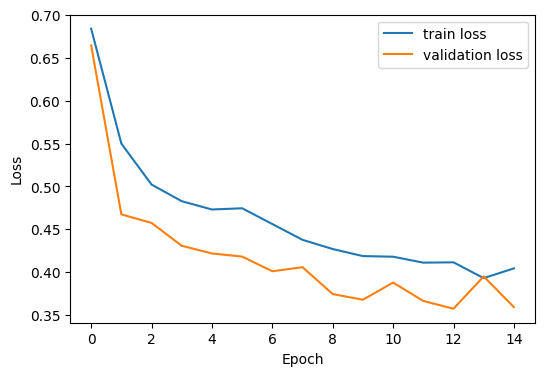

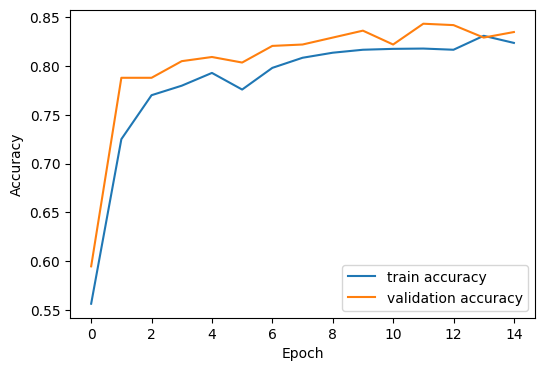

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8182 - loss: 0.4243
Test loss: 0.4243
Test accuracy: 0.8182


**Comentario sobre las curvas de entrenamiento**

El entrenamiento corrió las 15 épocas completas (no se activó el corte de EarlyStopping, que requiere 3 épocas seguidas sin mejora). La train accuracy sube de forma bastante monótona desde 0.556 (época 1) hasta \~0.82-0.83 (época 15), y la val accuracy la acompaña de cerca, terminando incluso un poco más alta (\~0.83-0.84). Igualmente, train loss y val loss bajan juntas desde \~0.68 hasta \~0.36-0.40, con la curva de validación siempre por debajo o muy cerca de la de entrenamiento.

Esto es un **entrenamiento razonable, sin overfitting marcado**: no hay una brecha creciente entre train y validación (que sería la señal clásica de overfitting), y ambas métricas mejoran de forma consistente. Se observa sí un leve repunte del val_loss en la época 14 (0.3951, tras un mínimo de 0.3575 en la época 13) antes de volver a bajar en la época 15 — un indicio temprano y leve de que el modelo empieza a sobreajustar, pero no lo suficientemente sostenido como para activar EarlyStopping. Gracias a restore_best_weights=True, el modelo final corresponde aproximadamente a los pesos de mejor val_loss durante el entrenamiento.

#### Genere la matriz de confusión y las métricas

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


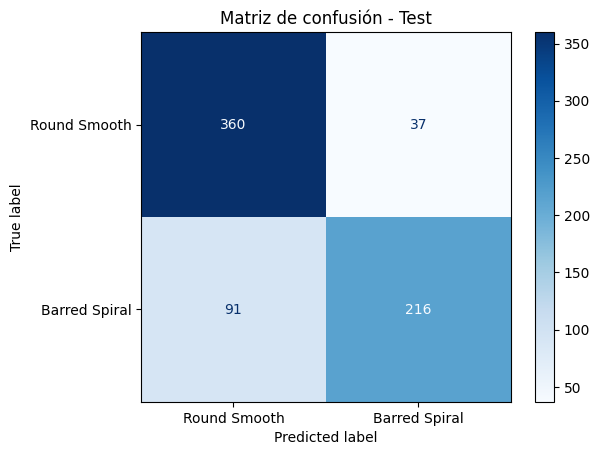

Precision: 0.8538
Recall:    0.7036
F1-score:  0.7714

               precision    recall  f1-score   support

 Round Smooth       0.80      0.91      0.85       397
Barred Spiral       0.85      0.70      0.77       307

     accuracy                           0.82       704
    macro avg       0.83      0.81      0.81       704
 weighted avg       0.82      0.82      0.82       704



In [ ]:
# Predicciones sobre el conjunto de test
y_prob = model.predict(X_test).ravel()
y_pred = (y_prob >= 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=[class_names[0], class_names[1]])
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión - Test")
plt.show()

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print()
print(classification_report(y_test, y_pred,
                             target_names=[class_names[0], class_names[1]]))

**¿Es suficiente el accuracy por sí solo?**

El accuracy de test fue **81.82%**, claramente por sobre el baseline de 56.42% (predecir siempre Round Smooth), así que el modelo sí está aprendiendo algo útil. Sin embargo, el accuracy solo esconde una asimetría importante entre clases:

| Clase | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Round Smooth | 0.80 | 0.91 | 0.85 | 397 |
| Barred Spiral | 0.85 | 0.70 | 0.77 | 307 |

La matriz de confusión (360 / 37 / 91 / 216) muestra que el modelo **recupera bien las Round Smooth** (recall 0.91) pero **se le escapan muchas Barred Spiral** (recall 0.70): 91 de las 307 galaxias barradas del test (≈30%) fueron clasificadas erróneamente como Round Smooth, mientras que solo 37 de las 397 Round Smooth (≈9%) fueron confundidas con Barred Spiral. Esto es consistente con el desbalance de clases (56%/44%) del dataset: el modelo tiende a favorecer la clase mayoritaria cuando la imagen es ambigua. Un accuracy global de 82% no deja ver esta diferencia de recall entre clases, por lo que conviene complementarlo siempre con la matriz de confusión y con precision/recall/F1 por clase.

#### Revise algunos ejemplos de galaxias mal clasificadas

Número de imágenes mal clasificadas: 128 de 704 (18.18%)


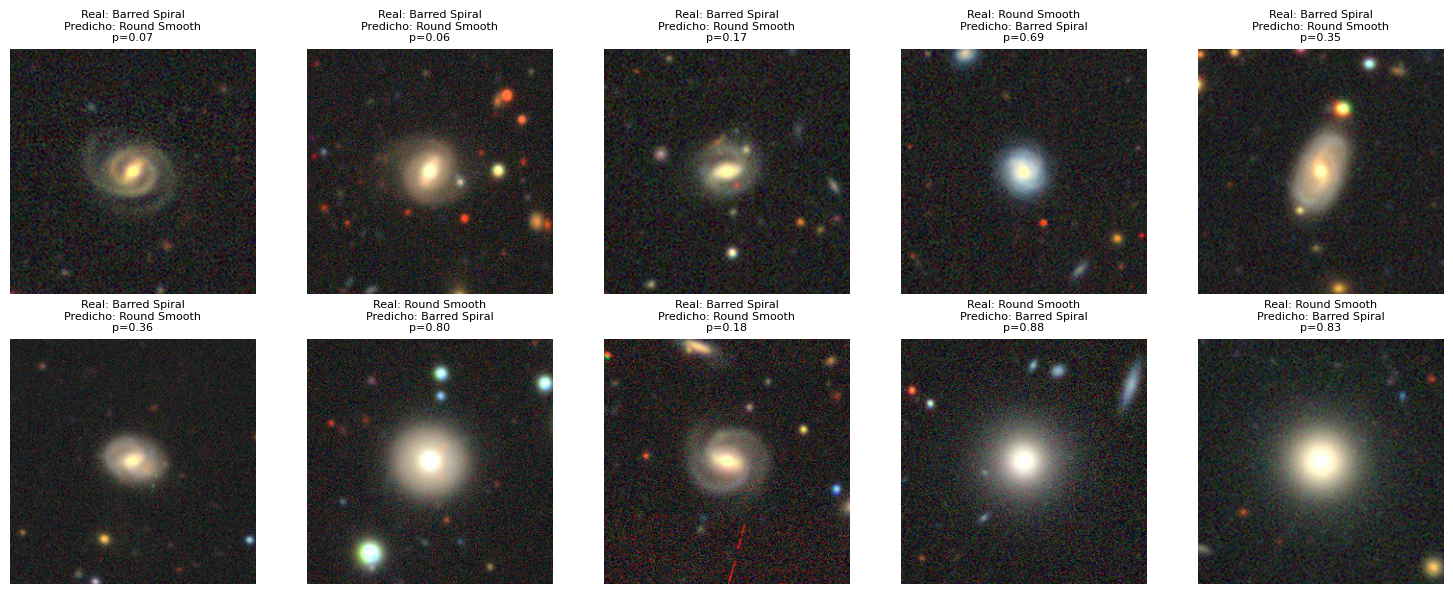

In [ ]:
# Índices de imágenes mal clasificadas en el set de test
misclassified_idx = np.where(y_pred != y_test)[0]
print(f"Número de imágenes mal clasificadas: {len(misclassified_idx)} "
      f"de {len(y_test)} ({100*len(misclassified_idx)/len(y_test):.2f}%)")

n_show = min(10, len(misclassified_idx))
rng2 = np.random.default_rng(42)
sample = rng2.choice(misclassified_idx, size=n_show, replace=False)

plt.figure(figsize=(15, 6))
for j, idx in enumerate(sample):
    plt.subplot(2, 5, j + 1)
    plt.imshow(X_test[idx])
    plt.title(f"Real: {class_names[y_test[idx]]}\n"
              f"Predicho: {class_names[y_pred[idx]]}\n"
              f"p={y_prob[idx]:.2f}", fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

**Análisis de errores**

De los 704 casos de test, **128 (18.18%)** fueron mal clasificados. Revisando la grilla de ejemplos:

- La mayoría de los **Barred Spiral clasificados como Round Smooth** (probabilidades bajas, p≈0.06–0.36) corresponden a galaxias de tamaño angular pequeño y brazos/barra poco marcados: la estructura espiral es tenue y ocupa pocos píxeles, por lo que a esa resolución se parece bastante a una mancha suave. Este parece un **error morfológicamente ambiguo** más que una falla evidente del modelo, ya que incluso a ojo cuesta distinguir la barra en esos casos.
- Los **Round Smooth clasificados como Barred Spiral** (probabilidades altas, p≈0.80–0.88) sí llaman más la atención: se ven como galaxias suaves y redondeadas sin barra visible, pero varias de ellas tienen **objetos cercanos contaminando la imagen** (otras galaxias o estrellas de campo visibles en el recuadro) y una de ellas incluye una marca roja (posible artefacto/anotación del catálogo). Esto sugiere que en estos casos el modelo podría estar reaccionando a **contaminación por objetos cercanos o artefactos de la imagen**, más que a una barra real.
- En general no se observan casos con baja resolución o desenfoque evidente entre los errores mostrados.

En síntesis: los errores hacia "Round Smooth" (falsos negativos de Barred Spiral) parecen sobre todo casos límite genuinos (barras débiles/pequeñas), mientras que los errores hacia "Barred Spiral" (falsos positivos) parecen más asociados a ruido/contaminación en la imagen que a una confusión morfológica real.

#### Conclusiones y comentarios finales

**Conclusiones y comentarios finales**

El modelo alcanzó un accuracy de test de **81.82%**, muy por sobre el baseline de predecir siempre la clase mayoritaria (56.42%), lo que indica que sí aprendió señal morfológica útil y no solo la proporción de clases del dataset. Las curvas de entrenamiento muestran una convergencia razonable, sin overfitting severo (train y validación se mueven juntas), aunque con un leve repunte de val_loss hacia el final que sugiere que entrenar más épocas sin regularización adicional probablemente empeoraría la generalización.

El análisis de errores es consistente con que el modelo **sí está captando diferencias morfológicas reales**: la mayoría de los falsos negativos de Barred Spiral corresponden a galaxias con barras pequeñas o poco marcadas, un caso genuinamente difícil incluso para un clasificador humano. Sin embargo, el patrón de los falsos positivos (Round Smooth predichas como Barred Spiral, asociadas a objetos cercanos o artefactos en la imagen) sugiere que el modelo **no es totalmente robusto** y en algunos casos podría estar usando pistas espurias (contaminación de la imagen, presencia de otros objetos) en vez de la forma de la galaxia central. La brecha de recall entre clases (0.91 vs. 0.70) también es coherente con el desbalance del dataset (56% / 44%): el modelo tiende a favorecer la clase mayoritaria cuando la imagen es ambigua. Una mejora natural sería aplicar aumentación de datos o ponderar la pérdida por clase para reducir ese sesgo hacia Round Smooth.